In [72]:
from pathlib import Path
import sys
import pandas as pd

# Make project root importable whether CWD is repo root or notebooks/
cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / 'src').exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.io import load_run, load_runs
from src.preprocess import (
    qc_report,
    plot_sanity,
    plot_dt_diagnostics,
    bias_from_first_seconds,
    time_range,
    sensor_channel_checks,
    save_qc_outputs,
    build_dataset_qc_table,
    split_qc_pass_fail,
)


In [73]:
# Select one run for detailed QC
RUN_DIR = PROJECT_ROOT / 'data' / 'raw' / 'test' / 'log_20260209_125910.654'
run = load_run(RUN_DIR, include_pose=False)
acc, gyro, odo = run.acc, run.gyro, run.odo

print('Run:', run.run_id)
for name, df in [('acc', acc), ('gyro', gyro), ('odo', odo)]:
    print(f'{name}: n={len(df)}, t_rel=[{df.t_rel.min():.3f}, {df.t_rel.max():.3f}] s')

acc.head(), gyro.head(), odo.head()


Run: log_20260209_125910.654
acc: n=29643, t_rel=[0.000, 355.707] s
gyro: n=29986, t_rel=[0.000, 359.821] s
odo: n=45205, t_rel=[0.000, 361.634] s


(              t      ax      ay      az   t_rel
 0  1.770638e+09 -0.1358  0.5183  0.8604  0.0002
 1  1.770638e+09 -0.1314  0.5161  0.8628  0.0123
 2  1.770638e+09 -0.1348  0.5171  0.8606  0.0245
 3  1.770638e+09 -0.1344  0.5156  0.8731  0.0364
 4  1.770638e+09 -0.1348  0.5166  0.8624  0.0484,
               t      gx      gy      gz   t_rel
 0  1.770638e+09 -3.4322 -9.8548 -1.6905  0.0000
 1  1.770638e+09 -3.4617 -9.5496 -1.6984  0.0112
 2  1.770638e+09 -3.5501 -9.5496 -1.7221  0.0233
 3  1.770638e+09 -3.7449 -9.4581 -1.5848  0.0353
 4  1.770638e+09 -3.4890 -9.5496 -1.8321  0.0472,
               t   v1   v2   t_rel
 0  1.770638e+09 -0.0  0.0  0.0001
 1  1.770638e+09 -0.0  0.0  0.0078
 2  1.770638e+09 -0.0  0.0  0.0157
 3  1.770638e+09 -0.0  0.0  0.0244
 4  1.770638e+09 -0.0  0.0  0.0320)

In [74]:
# Single-run QC report table
single_run_qc = qc_report(run.sensors(), tcol='t_rel').set_index('sensor')
single_run_qc


,n,duration_s,fs_med_hz,dt_med,dt_p99,dt_max,gap_ratio_dtmax_over_dtmed,n_gaps_gt_factor_times_med
sensor,,,,,,,,
acc,29643,355.7067,83.332751,0.0120,0.0130,0.0172,1.433323,0
gyro,29986,359.8211,83.332751,0.0120,0.0130,0.0170,1.416673,0
odo,45205,361.6337,129.870696,0.0077,0.0088,0.0138,1.792234,0


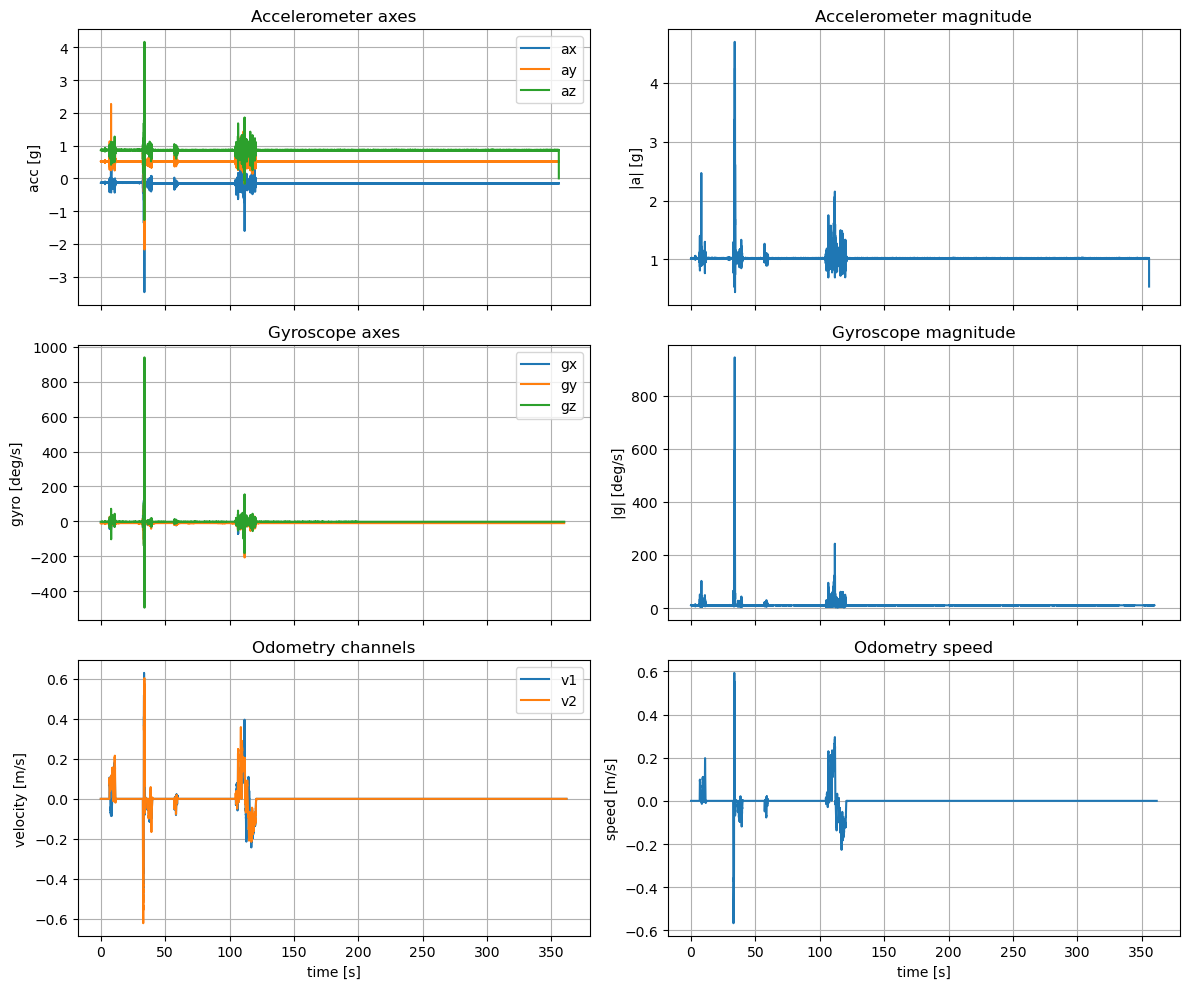

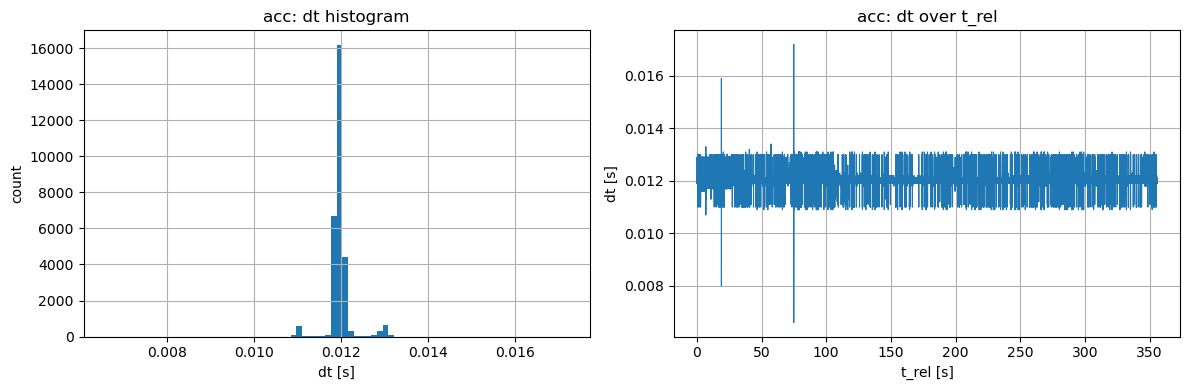

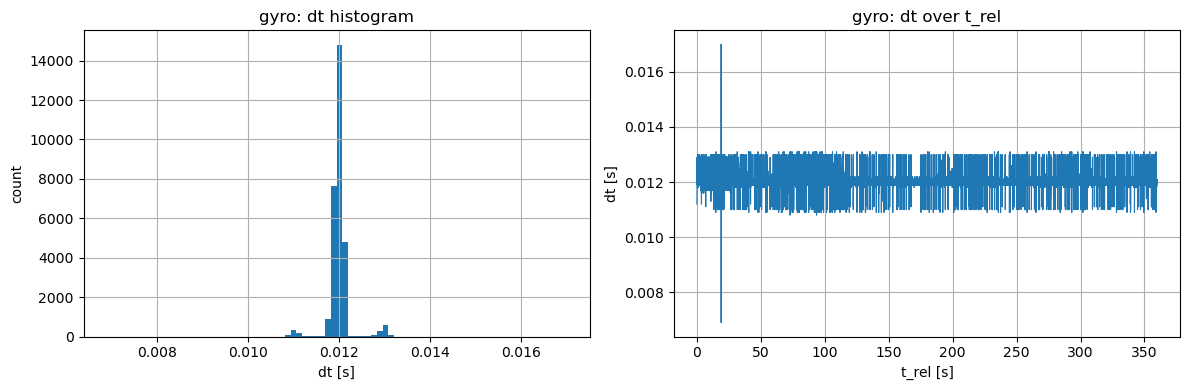

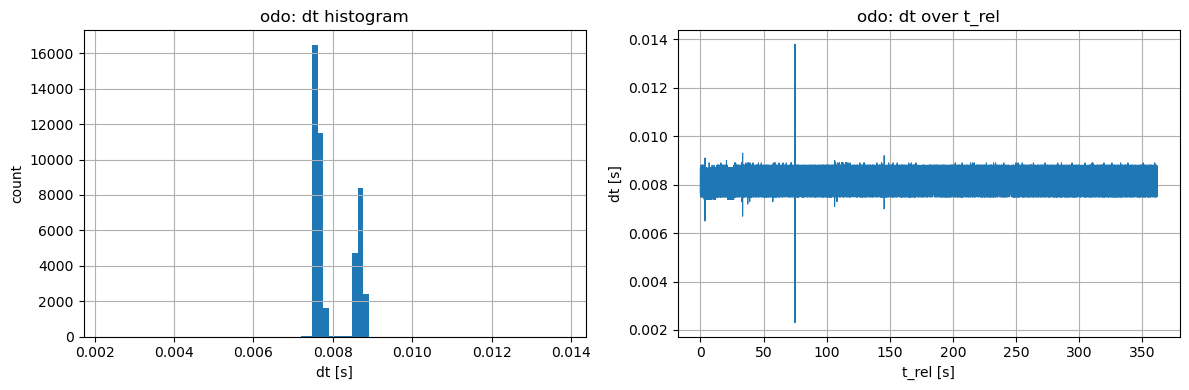

In [75]:
# Single-run sanity plots + dt diagnostics
plot_sanity(acc, gyro, odo, tcol='t_rel', show=True)
for sensor_name, df in [('acc', acc), ('gyro', gyro), ('odo', odo)]:
    fig = plot_dt_diagnostics(sensor_name, df, tcol='t_rel', bins=80, show=True)
    if fig is None:
        print(f'{sensor_name}: not enough samples for dt diagnostics')


In [76]:
# Bias/time-range and sensor saturation checks
gyro_bias = bias_from_first_seconds(gyro, ['gx', 'gy', 'gz'], tcol='t_rel', seconds=5)
acc_bias = bias_from_first_seconds(acc, ['ax', 'ay', 'az'], tcol='t_rel', seconds=5)
acc_mag_median_5s = ((acc['ax']**2 + acc['ay']**2 + acc['az']**2) ** 0.5)[acc['t_rel'] <= 5].median()

print('Gyro bias (first 5s):')
print(gyro_bias)
print('\nAcc mean (first 5s):')
print(acc_bias)
print('\nAcc |a| median (first 5s):', float(acc_mag_median_5s) if pd.notna(acc_mag_median_5s) else float('nan'))

ranges = pd.DataFrame(
    {
        'sensor': ['acc', 'gyro', 'odo'],
        't_min': [time_range(acc)[0], time_range(gyro)[0], time_range(odo)[0]],
        't_max': [time_range(acc)[1], time_range(gyro)[1], time_range(odo)[1]],
    }
).set_index('sensor')
print('\nTime ranges (t_rel):')
ranges

range_sat_checks = pd.concat(
    [
        sensor_channel_checks(acc, ['ax', 'ay', 'az'], 'acc'),
        sensor_channel_checks(gyro, ['gx', 'gy', 'gz'], 'gyro'),
    ],
    ignore_index=True,
)
print('\nRange/saturation checks:')
range_sat_checks


Gyro bias (first 5s):
gx   -3.516306
gy   -9.542891
gz   -1.699889
dtype: float64

Acc mean (first 5s):
ax   -0.135394
ay    0.516840
az    0.865484
dtype: float64

Acc |a| median (first 5s): 1.0171793548829036

Time ranges (t_rel):

Range/saturation checks:


,sensor,channel,max_abs,n,n_unique,repeat_ratio,longest_constant_run,clip_candidate_count,flag_frozen,flag_flat_top
0,acc,ax,3.4717,29643,1647,0.011706,3,1,False,False
1,acc,ay,2.9382,29643,1176,0.029923,3,1,False,False
2,acc,az,4.1660,29643,1820,0.007489,3,1,False,False
3,gyro,gx,500.3395,29986,3067,0.004269,3,1,False,False
4,gyro,gy,439.7607,29986,1001,0.057460,6,1,False,False
5,gyro,gz,938.2430,29986,3071,0.004269,3,1,False,False


In [77]:
# Save QC artifacts per run (mirrors data/raw labels under reports/raw)
RAW_ROOT = PROJECT_ROOT / 'data' / 'raw'
ARTIFACT_ROOT = PROJECT_ROOT / 'reports' / 'raw'
runs_for_artifacts = load_runs(RAW_ROOT, include_pose=False)
save_qc_outputs(runs_for_artifacts, raw_root=RAW_ROOT, out_root=ARTIFACT_ROOT, tcol='t_rel')
print(f'Saved QC artifacts for {len(runs_for_artifacts)} runs to: {ARTIFACT_ROOT}')


Saved QC artifacts for 4 runs to: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/raw


In [78]:
# Multi-run QC dashboard + pass/fail filtering
RAW_ROOT = PROJECT_ROOT / 'data' / 'raw'
runs = load_runs(RAW_ROOT, include_pose=False)

dataset_qc = build_dataset_qc_table(runs, tcol='t_rel', min_duration_s=30.0)
dataset_qc_good, dataset_qc_bad, good_run_ids, bad_run_ids = split_qc_pass_fail(dataset_qc)

print('Good runs:', len(good_run_ids))
print(good_run_ids)
print('Bad runs:', len(bad_run_ids))
print(bad_run_ids)

dataset_qc


Good runs: 2
['log_20251222_120952.855', 'log_20260209_125910.654']
Bad runs: 2
['log_20251219_134611.366', 'log_20251222_115149.656']


,acc__n,acc__duration_s,acc__fs_med_hz,acc__dt_med,acc__dt_p99,acc__dt_max,acc__gap_ratio_dtmax_over_dtmed,acc__n_gaps_gt_factor_times_med,gyro__n,gyro__duration_s,gyro__fs_med_hz,gyro__dt_med,gyro__dt_p99,gyro__dt_max,gyro__gap_ratio_dtmax_over_dtmed,gyro__n_gaps_gt_factor_times_med,odo__n,odo__duration_s,odo__fs_med_hz,odo__dt_med,odo__dt_p99,odo__dt_max,odo__gap_ratio_dtmax_over_dtmed,odo__n_gaps_gt_factor_times_med,pass_dt_gaps,pass_duration,pass_fs,pass_all
run_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,
log_20251219_134611.366,5.0,0.0483,82.987327,0.01205,0.012197,0.0122,1.012435,0.0,5.0,0.0485,83.333578,0.012,0.013164,0.0132,1.100007,0.0,7.0,0.0483,128.203448,0.0078,0.0087,0.0087,1.115356,0.0,True,False,True,False
log_20251222_115149.656,24801.0,297.6012,83.334406,0.01200,0.013000,0.5222,43.517236,1.0,24801.0,297.6003,83.334406,0.012,0.013000,0.5222,43.517236,1.0,37201.0,297.6001,129.870696,0.0077,0.0088,0.5179,67.260032,1.0,False,True,True,False
log_20251222_120952.855,12437.0,149.2332,83.332751,0.01200,0.013000,0.0131,1.091671,0.0,12437.0,149.2343,83.332751,0.012,0.013000,0.0132,1.099996,0.0,18656.0,149.2401,129.870696,0.0077,0.0088,0.0097,1.259754,0.0,True,True,True,True
log_20260209_125910.654,29643.0,355.7067,83.332751,0.01200,0.013000,0.0172,1.433323,0.0,29986.0,359.8211,83.332751,0.012,0.013000,0.0170,1.416673,0.0,45205.0,361.6337,129.870696,0.0077,0.0088,0.0138,1.792234,0.0,True,True,True,True
